# Homework 1 - Machine Learning

### Luther Williams

In [18]:
import pandas as pd
import jax as jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

In [19]:
insurance_df = pd.read_csv('insurance.csv')

In [20]:
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
x_data = insurance_df.drop(columns=['charges'])
y_data = insurance_df['charges'].values

In [22]:
def linear_regression(params, x):
    return jnp.dot(x, params)

def least_squares_loss(params, x, y):
    predictions = linear_regression(params, x)

    return ((y - predictions) ** 2)

In [23]:
def prepare_data(x_df):
    x_processed = x_df.copy()
    x_processed['sex'] = x_processed['sex'].map({'male': 0, 'female': 1})
    x_processed['smoker'] = x_processed['smoker'].map({'no': 0, 'yes': 1})
    x_processed['region'] = x_processed['region'].map({'northwest': 0, 'northeast': 1, 'southwest': 2, 'southeast': 3})

    return x_processed

In [24]:
key = jax.random.PRNGKey(42)
params = jax.random.normal(key, (x_data.shape[1],))
x_data = prepare_data(x_data)
x_jax = jnp.array(x_data.values)
y_jax = jnp.array(y_data)


In [25]:
print("Input features shape:", x_jax.shape)
print("Parameters shape:", params.shape)
print("Target values shape:", y_jax.shape)

Input features shape: (1338, 6)
Parameters shape: (6,)
Target values shape: (1338,)


In [26]:
res = linear_regression(params, x_data.values)
print("Initial predictions:", res)

Initial predictions: [ 0.76378773  4.70728044  3.94075333 ...  2.50095202 -0.48782537
 -7.51339958]


In [27]:
# LSE
initial_loss = least_squares_loss(params=params,x=x_jax,y=y_jax)

In [28]:
import jax.numpy as jnp

def normal_equation_inv(X, y):
    """Normal equation θ=(X^TX)^-1X^Ty"""
    term1 = jnp.linalg.inv(jnp.dot(X.T, X))
    term2 = jnp.dot(X.T, y)
    return jnp.dot(term1, term2)

In [29]:
# Minimize LSE using normal equation
params = normal_equation_inv(x_jax, y_jax)
print("Parameters from normal equation:", params)
print("Predictions from normal equation:", linear_regression(params, x_jax))


Parameters from normal equation: [  199.97941995  -755.06673478    53.773517     238.04769336
 23308.8030125   -336.53454006]
Predictions from normal equation: [27180.55730088  4644.00530128  7078.48927942 ...  3816.51330549
  4158.78874259 36315.67703382]


In [30]:
N = x_jax.shape[0]  
rss = jnp.sum(least_squares_loss(params, x_jax, y_jax))

mse = rss / N

rmse = jnp.sqrt(mse)

y_mean = jnp.mean(y_jax)
total_variance = jnp.sum((y_jax - y_mean) ** 2)
r2_score = 1 - (rss / total_variance)

print(f"Residual Sum of Squares (RSS): {rss:,.0f}")
print(f"Mean Squared Error (MSE):      {mse:,.0f}")
print(f"RMSE (Average Error):          {rmse:,.2f}")

Residual Sum of Squares (RSS): 54,776,985,993
Mean Squared Error (MSE):      40,939,451
RMSE (Average Error):          6,398.39


In [31]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import jax.numpy as jnp

# Load breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the data properly into training (90%) and testing (10%)
# 90% training, 10% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

# Convert to JAX arrays
X_train_jax = jnp.array(X_train)
y_train_jax = jnp.array(y_train)
X_test_jax = jnp.array(X_test)
y_test_jax = jnp.array(y_test)

print("Training set shape:", X_train_jax.shape)
print("Testing set shape:", X_test_jax.shape)

Training set shape: (512, 30)
Testing set shape: (57, 30)


In [ ]:
params_cancer = normal_equation_inv(X_train_jax, y_train_jax)

In [ ]:
# Make predictions on the test set
y_pred_continuous = linear_regression(params_cancer, X_test_jax)

# Convert regression output to binary class labels
y_pred_class = (y_pred_continuous >= 0.5).astype(int)

# True Positives
tp = jnp.sum((y_pred_class == 1) & (y_test_jax == 1))

# False Positives
fp = jnp.sum((y_pred_class == 1) & (y_test_jax == 0))

# True Negatives 
tn = jnp.sum((y_pred_class == 0) & (y_test_jax == 0))

# False Negatives
fn = jnp.sum((y_pred_class == 0) & (y_test_jax == 1))

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = jnp.where((tp + fp) > 0, tp / (tp + fp), 0.0)

print(f"Accuracy on test set: {accuracy:.4f}")
print(f"Precision on test set: {precision:.4f}")

Accuracy on test set: 0.8947
Precision on test set: 0.9048


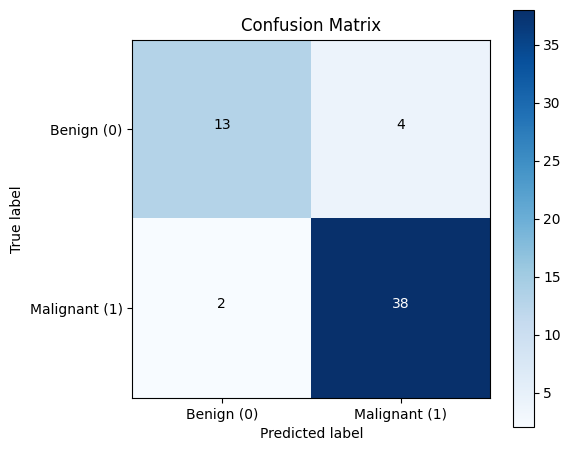

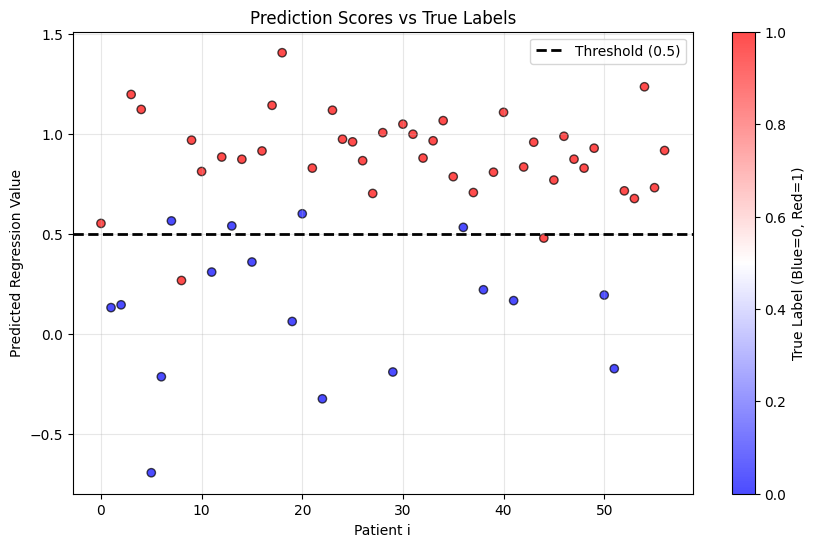

In [ ]:
import matplotlib.pyplot as plt

cm_values = [[int(tn), int(fp)], [int(fn), int(tp)]]

#Confusion Matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm_values, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, ['Benign (0)', 'Malignant (1)'])
plt.yticks(tick_marks, ['Benign (0)', 'Malignant (1)'])

thresh = (int(tp) + int(tn) + int(fp) + int(fn)) / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm_values[i][j]),
                 horizontalalignment="center",
                 color="white" if cm_values[i][j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test_jax)), y_pred_continuous, c=y_test_jax, cmap='bwr', alpha=0.7, edgecolor='k')
plt.axhline(y=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
plt.colorbar(label='True Label (Blue=0, Red=1)')
plt.xlabel('Patient i')
plt.ylabel('Predicted Regression Value')
plt.title('Prediction Scores vs True Labels')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()